In [ ]:
!git clone https://github.com/EnergyBasedFlowClassifier/EFC-package.git
%cd EFC-package
!pip install -r requirements.txt
!pip install --no-build-isolation .
%cd /content/EFC-package
!python setup.py build_ext --inplace
!pip install --no-build-isolation -e .
!pip install imbalanced-learn
!pip install lightgbm

from google.colab import drive
import os
drive.mount("/content/drive", force_remount = True)
path = "/content/drive/My Drive/TCC/Dataset-final"
if os.path.isdir(path):
  !ls "{path}"

In [9]:
from sklearn.metrics import classification_report, f1_score, balanced_accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, StackingClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from efc import EnergyBasedFlowClassifier
from lightgbm import LGBMClassifier
from joblib import parallel_backend
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import copy

In [3]:
# Carrego o meu dataset balanceado
balanced_df_atack_category = pd.read_csv(f"{path}/balanced_df_atack_category.csv")

# Defino oq é saída e oq é entrada
X = balanced_df_atack_category.select_dtypes(include = np.number)
y = balanced_df_atack_category['Label']

# Divisão em teste e treinamento
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y)

# Codificação dos rótulos
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

le_kfold = LabelEncoder()
y_encoded_kfold = le_kfold.fit_transform(y)

In [4]:
balanced_df_atack_category

,Header_Length,Protocol_Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,...,Tot_sum,Min,Max,AVG,Std,Tot_size,IAT,Number,Variance,Label
0,0.00,1,64.00,80120.420248,0.0,0.0,0.0,0.00,0.00,0.0,...,6000,60,60,60.00,0.000000,60.00,0.000013,100,0.000000,DDoS
1,8.00,17,64.00,76454.684652,0.0,0.0,0.0,0.00,0.00,0.0,...,6000,60,60,60.00,0.000000,60.00,0.000013,100,0.000000,DDoS
2,0.00,1,64.00,20488.003126,0.0,0.0,0.0,0.00,0.00,0.0,...,6000,60,60,60.00,0.000000,60.00,0.000049,100,0.000000,DoS
3,29.96,6,113.03,35.137120,0.0,0.0,0.0,0.30,0.93,0.0,...,10004,60,827,100.04,113.939459,100.04,0.029393,100,12982.200404,Benign
4,28.72,6,61.33,16.788267,0.0,0.0,0.0,0.41,0.89,0.0,...,8719,42,928,87.19,89.146196,87.19,0.059565,100,7947.044343,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47995,8.00,17,64.00,112.115090,0.0,0.0,0.0,0.00,0.00,0.0,...,2676,102,1226,267.60,342.840488,267.60,0.009197,10,117539.600000,Spoofing
47996,20.00,6,64.00,16028.370529,0.0,0.0,0.0,0.00,0.00,0.0,...,6000,60,60,60.00,0.000000,60.00,0.000062,100,0.000000,DoS
47997,0.00,1,64.00,57080.892760,0.0,0.0,0.0,0.00,0.00,0.0,...,6000,60,60,60.00,0.000000,60.00,0.000018,100,0.000000,DDoS
47998,30.32,6,64.02,16.674676,0.0,0.0,0.0,0.47,0.93,0.0,...,9631,66,929,96.31,91.910551,96.31,0.059971,100,8447.549394,Benign


# K-Fold variando de 2 a 15 "dobras" no dataset

In [14]:
k_values = range(2, 11)
results_avg_f1 = []
results_std_f1 = []

best_global_f1 = 0
best_global_model = None
best_global_X_test = None
best_global_y_test = None
best_global_k = 0

for k in k_values:
    skf = StratifiedKFold(n_splits = k, shuffle = True, random_state = 42)
    fold_scores = []
    for train_index, test_index in skf.split(X, y):
        X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
        y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]
        y_train_encoded_fold = le.fit_transform(y_train_fold)
        y_test_encoded_fold = le.transform(y_test_fold)

        model = EnergyBasedFlowClassifier(n_bins = 30,
                                          cutoff_quantile=0.90,
                                          n_jobs = 1)

        model.fit(X_train_fold, y_train_encoded_fold)

        y_pred_fold = model.predict(X_test_fold)
        score = f1_score(y_test_encoded_fold, y_pred_fold, average = 'macro', zero_division = 0)
        fold_scores.append(score)

        if score > best_global_f1:
            best_global_f1 = score
            best_global_k = k
            best_global_model = copy.deepcopy(model)
            best_global_X_test = X_test_fold.copy()
            best_global_y_test = y_test_encoded_fold.copy()

    avg_score = np.mean(fold_scores)
    std_score = np.std(fold_scores)
    results_avg_f1.append(avg_score)
    results_std_f1.append(std_score)

    print(f"-> K = {k:02d}: Média F1 = {avg_score:.4f} (+/- {std_score:.4f})")

print(f"\nMelhor Fold:")
print(f"  K = {best_global_k}")
print(f"  F1-Score = {best_global_f1:.4f}")

-> K = 02: Média F1 = 0.8717 (+/- 0.0124)
-> K = 03: Média F1 = 0.8695 (+/- 0.0064)
-> K = 04: Média F1 = 0.8673 (+/- 0.0051)
-> K = 05: Média F1 = 0.8691 (+/- 0.0061)
-> K = 06: Média F1 = 0.8687 (+/- 0.0053)
-> K = 07: Média F1 = 0.8678 (+/- 0.0047)
-> K = 08: Média F1 = 0.8660 (+/- 0.0060)
-> K = 09: Média F1 = 0.8664 (+/- 0.0060)

Melhor Fold:
  K = 2
  F1-Score = 0.8840


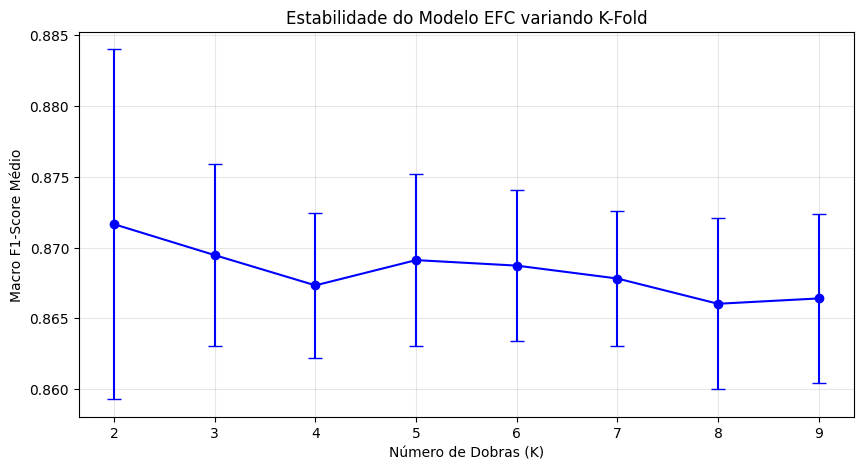

In [15]:
plt.figure(figsize=(10, 5))
plt.errorbar(k_values, results_avg_f1, yerr = results_std_f1, fmt = '-o', capsize = 5, color = 'blue')
plt.title("Estabilidade do Modelo EFC variando K-Fold")
plt.xlabel("Número de Dobras (K)")
plt.ylabel("Macro F1-Score Médio")
plt.grid(True, alpha = 0.3)
plt.show()

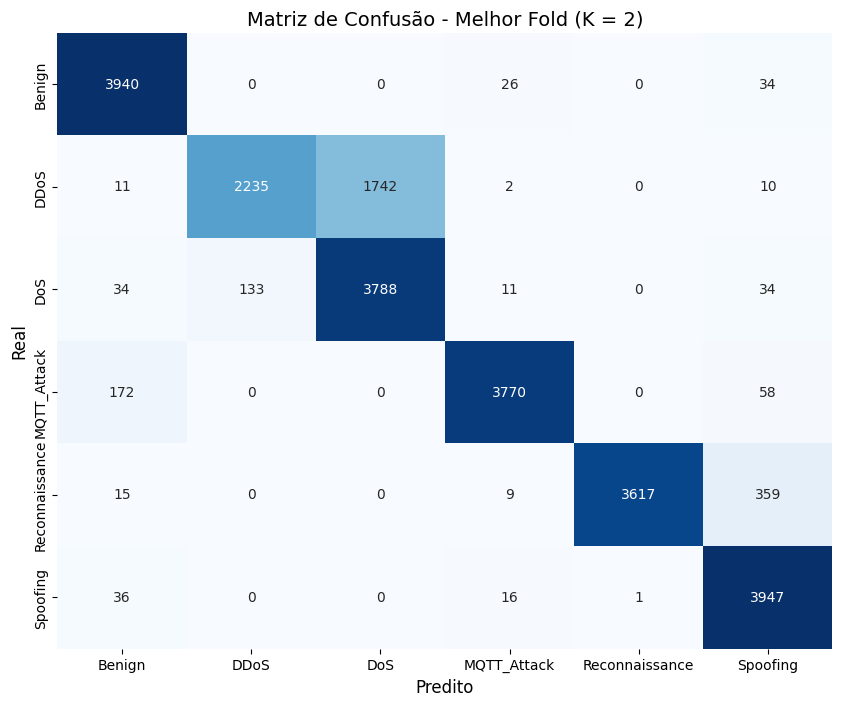

In [16]:
y_pred_best = best_global_model.predict(best_global_X_test)
cm = confusion_matrix(best_global_y_test, y_pred_best)

plt.figure(figsize = (10, 8))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues',
            xticklabels = le.classes_,
            yticklabels = le.classes_,
            cbar = False)

plt.title(f"Matriz de Confusão - Melhor Fold (K = {best_global_k})", fontsize = 14)
plt.ylabel('Real', fontsize = 12)
plt.xlabel('Predito', fontsize = 12)
plt.show()

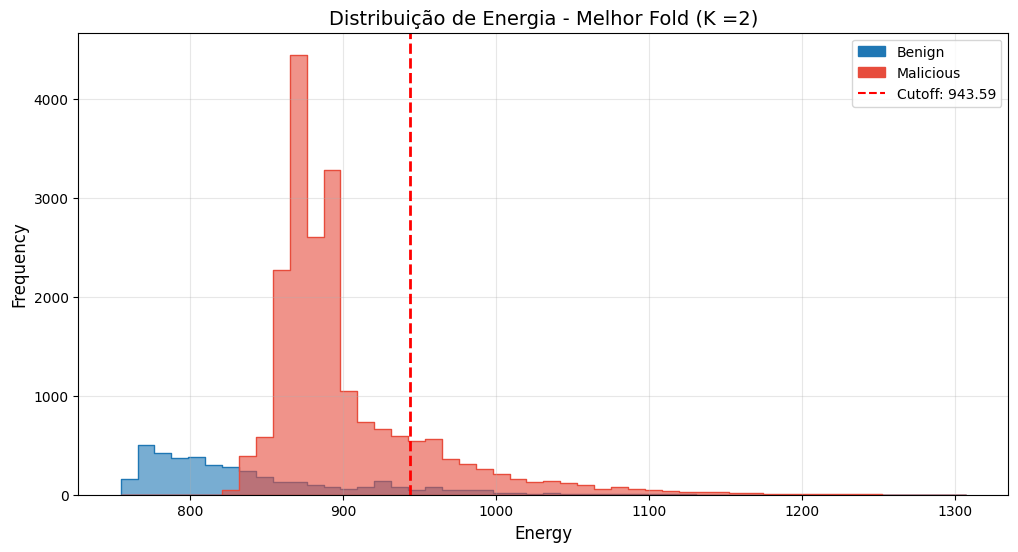

In [13]:
_, energies = best_global_model.predict(best_global_X_test, return_energies = True)

df_viz = pd.DataFrame()
df_viz['Energy'] = energies
df_viz['Label'] = le.inverse_transform(best_global_y_test)
df_viz['Tipo'] = df_viz['Label'].apply(lambda x: 'Benign' if x == 'Benign' else 'Malicious')

idx_benign = le.transform(['Benign'])[0]
cutoff_oficial = best_global_model.estimators_[idx_benign].cutoff_

plt.figure(figsize=(12, 6))

sns.histplot(data=df_viz, x = "Energy", hue = "Tipo",
             element = "step", fill = True, stat = "count",
             bins = 50, alpha = 0.6,
             palette = {"Benign": "#1f77b4", "Malicious": "#E74C3C"},
             legend = False)

plt.axvline(cutoff_oficial, color = 'red', linestyle = '--', linewidth = 2)

legenda_azul = mpatches.Patch(color = "#1f77b4", label = 'Benign')
legenda_vermelho = mpatches.Patch(color = "#E74C3C", label = 'Malicious')
legenda_linha = mlines.Line2D([], [], color = 'red', linestyle = '--', label = f'Cutoff: {cutoff_oficial:.2f}')

plt.legend(handles = [legenda_azul, legenda_vermelho, legenda_linha], loc = 'upper right')

plt.title(f"Distribuição de Energia - Melhor Fold (K ={best_global_k})", fontsize = 14)
plt.xlabel("Energy", fontsize = 12)
plt.ylabel("Frequency", fontsize = 12)
plt.grid(True, alpha = 0.3)
plt.show()

# Teste usando o LGBMC

In [17]:
model = LGBMClassifier(
        n_estimators = 10,
        n_jobs = 1,
        objective = 'multiclass',
        num_class = 6,
        verbose = -1
    )

model.fit(X_train, y_train_encoded)
y_pred = model.predict(X_test)
print("\n--- Relatório de Avaliação (LightGBM) ---\n")
print(classification_report(y_test_encoded, y_pred, target_names = le.classes_))


--- Relatório de Avaliação (LightGBM) ---

                precision    recall  f1-score   support

        Benign       0.99      1.00      0.99      1600
          DDoS       0.89      0.77      0.83      1600
           DoS       0.80      0.90      0.85      1600
   MQTT_Attack       1.00      0.98      0.99      1600
Reconnaissance       0.99      0.92      0.96      1600
      Spoofing       0.92      0.99      0.95      1600

      accuracy                           0.93      9600
     macro avg       0.93      0.93      0.93      9600
  weighted avg       0.93      0.93      0.93      9600



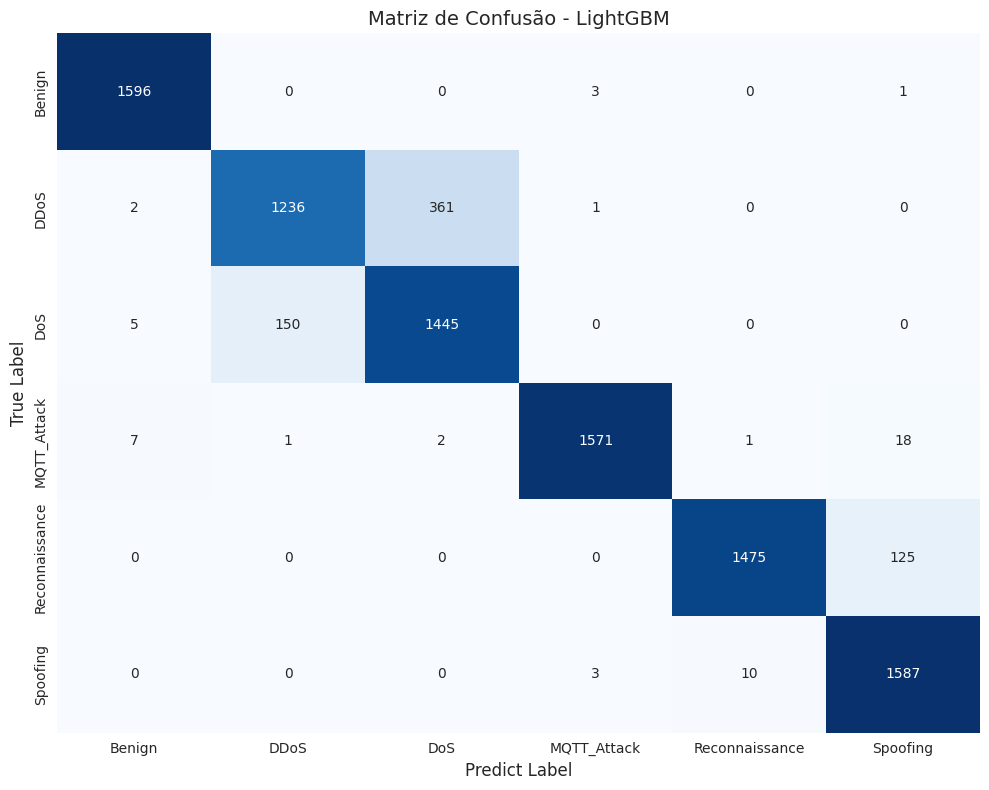

In [18]:
cm = confusion_matrix(y_test_encoded, y_pred)
classes = le.classes_
plt.figure(figsize = (10, 8))
sns.set_style("whitegrid")

sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues',
            xticklabels = classes,
            yticklabels = classes,
            cbar = False)

plt.title("Matriz de Confusão - LightGBM", fontsize = 14)
plt.ylabel('True Label', fontsize = 12)
plt.xlabel('Predict Label', fontsize = 12)
plt.tight_layout()
plt.show()

# Classificador de Empilhamento

## LGBM + EFC

In [19]:
estimators_1 = [
    ('lgbm', LGBMClassifier(
        n_estimators = 10,
        n_jobs = 1,
        objective = 'multiclass',
        num_class = 6,
        verbose = -1
    )),
    ('efc', EnergyBasedFlowClassifier(
        n_bins = 30,
        cutoff_quantile = 0.90,
        n_jobs = 1
    ))
]

stack_model_1 = StackingClassifier(
    estimators = estimators_1,
    final_estimator = LogisticRegression(),
    cv = 3,
    n_jobs = 1
)
stack_model_1.fit(X_train, y_train_encoded)
y_pred_1 = stack_model_1.predict(X_test)
print("\n--- Relatório de Avaliação (LGBM + EFC) ---\n")
print(classification_report(y_test_encoded, y_pred_1, target_names = le.classes_))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



--- Relatório de Avaliação (LGBM + EFC) ---

                precision    recall  f1-score   support

        Benign       0.99      1.00      1.00      1600
          DDoS       0.89      0.78      0.83      1600
           DoS       0.80      0.90      0.85      1600
   MQTT_Attack       0.99      0.98      0.99      1600
Reconnaissance       0.98      0.93      0.95      1600
      Spoofing       0.92      0.98      0.95      1600

      accuracy                           0.93      9600
     macro avg       0.93      0.93      0.93      9600
  weighted avg       0.93      0.93      0.93      9600



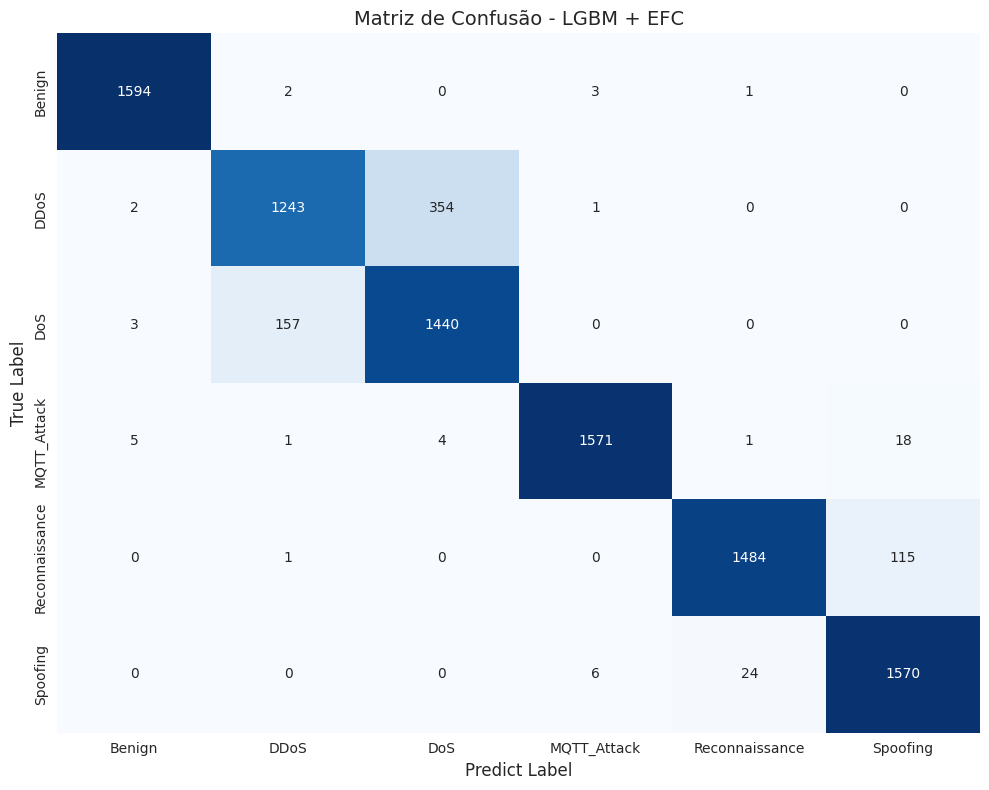

In [20]:
cm = confusion_matrix(y_test_encoded, y_pred_1)
classes = le.classes_
plt.figure(figsize = (10, 8))
sns.set_style("whitegrid")

sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues',
            xticklabels = classes,
            yticklabels = classes,
            cbar = False)

plt.title("Matriz de Confusão - LGBM + EFC", fontsize = 14)
plt.ylabel('True Label', fontsize = 12)
plt.xlabel('Predict Label', fontsize = 12)
plt.tight_layout()
plt.show()

## EFC + RF

In [ ]:
estimators_2 = [
    ('efc', EnergyBasedFlowClassifier(
        n_bins = 30,
        cutoff_quantile = 0.90,
        n_jobs=1
    )),
    ('rf', RandomForestClassifier(
        n_estimators = 10,
        n_jobs=1
    ))
]

stack_model_2 = StackingClassifier(
    estimators = estimators_2,
    final_estimator = LogisticRegression(),
    cv = 3,
    n_jobs = 1
)
stack_model_2.fit(X_train, y_train_encoded)
y_pred_2 = stack_model_2.predict(X_test)
print("\n--- Relatório de Avaliação (EFC + RF) ---\n")
print(classification_report(y_test_encoded, y_pred_2, target_names = le.classes_))



--- Relatório de Avaliação (RF + LGBM) ---

                precision    recall  f1-score   support

        Benign       1.00      1.00      1.00      1400
          DDoS       0.81      0.75      0.78      1400
           DoS       0.77      0.82      0.80      1400
   MQTT_Attack       0.99      0.99      0.99      1400
Reconnaissance       0.97      0.95      0.96      1400
      Spoofing       0.94      0.96      0.95      1400

      accuracy                           0.91      8400
     macro avg       0.91      0.91      0.91      8400
  weighted avg       0.91      0.91      0.91      8400



## RF + LGBM

In [ ]:
estimators_3 = [
    ('rf', RandomForestClassifier(
        n_estimators = 10,
        n_jobs = 1
    )),
    ('lgbm', LGBMClassifier(
        n_estimators=10,
        n_jobs = 1,
        objective = 'multiclass',
        num_class = 6,
        verbose=-1
    ))
]

stack_model_3 = StackingClassifier(
    estimators = estimators_3,
    final_estimator = LogisticRegression(),
    cv = 3,
    n_jobs= 1
)
stack_model_3.fit(X_train, y_train_encoded)
y_pred_3 = stack_model_3.predict(X_test)
print("\n--- Relatório de Avaliação (RF + LGBM) ---\n")
print(classification_report(y_test_encoded, y_pred_3, target_names = le.classes_))


--- Relatório de Avaliação (RF + LGBM) ---

                precision    recall  f1-score   support

        Benign       1.00      1.00      1.00      1400
          DDoS       0.89      0.76      0.82      1400
           DoS       0.79      0.90      0.84      1400
   MQTT_Attack       0.99      0.99      0.99      1400
Reconnaissance       0.98      0.94      0.96      1400
      Spoofing       0.93      0.98      0.96      1400

      accuracy                           0.93      8400
     macro avg       0.93      0.93      0.93      8400
  weighted avg       0.93      0.93      0.93      8400



## LGBM + LGBM

In [ ]:
estimators_4 = [
    ('lgbm_1', LGBMClassifier(
        n_estimators=10,
        n_jobs = 1,
        objective = 'multiclass',
        num_class = 6,
        verbose = -1
    )),
    ('lgbm_2', LGBMClassifier(
        n_estimators=10,
        n_jobs = 1,
        objective = 'multiclass',
        num_class = 6,
        verbose = -1
    ))
]

stack_model_4 = StackingClassifier(
    estimators = estimators_4,
    final_estimator = LogisticRegression(),
    cv = 3,
    n_jobs= 1
)
stack_model_4.fit(X_train, y_train_encoded)
y_pred_4 = stack_model_4.predict(X_test)
print("\n--- Relatório de Avaliação (LGBM + LGBM) ---\n")
print(classification_report(y_test_encoded, y_pred_4, target_names = le.classes_))


--- Relatório de Avaliação (LGBM + LGBM) ---

                precision    recall  f1-score   support

        Benign       0.99      1.00      0.99      1400
          DDoS       0.89      0.76      0.82      1400
           DoS       0.79      0.91      0.84      1400
   MQTT_Attack       0.99      0.98      0.99      1400
Reconnaissance       0.98      0.94      0.96      1400
      Spoofing       0.93      0.98      0.95      1400

      accuracy                           0.92      8400
     macro avg       0.93      0.92      0.92      8400
  weighted avg       0.93      0.92      0.92      8400

